# 08 — Model Comparison

In [1]:
# ============================================================
# 08 - Model Comparison
# Health Budget ML Project
# ============================================================

"""
Objective
---------
Compare the budget prediction models developed in Notebook 05.

Models:
1. Linear Regression
2. Random Forest
3. XGBoost

Evaluation metrics:
- MAE
- RMSE
- R2

This notebook also summarizes the current status of:
- Budget ML
- HMIS Health Analytics
- Infrastructure Analytics

Important:
This notebook does not create artificial ML metrics for the
health or infrastructure modules. Those modules are currently
analytics/prototype scoring modules rather than validated
forecasting models.
"""

'\nObjective\n---------\nCompare the budget prediction models developed in Notebook 05.\n\nModels:\n1. Linear Regression\n2. Random Forest\n3. XGBoost\n\nEvaluation metrics:\n- MAE\n- RMSE\n- R2\n\nThis notebook also summarizes the current status of:\n- Budget ML\n- HMIS Health Analytics\n- Infrastructure Analytics\n\nImportant:\nThis notebook does not create artificial ML metrics for the\nhealth or infrastructure modules. Those modules are currently\nanalytics/prototype scoring modules rather than validated\nforecasting models.\n'

# Imports and paths

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Project path
# ------------------------------------------------------------

current_path = Path.cwd()

if current_path.name == "notebooks":
    PROJECT_ROOT = current_path.parent
elif (current_path / "data").exists():
    PROJECT_ROOT = current_path
elif (current_path.parent / "data").exists():
    PROJECT_ROOT = current_path.parent
else:
    PROJECT_ROOT = current_path


# ------------------------------------------------------------
# Directories
# ------------------------------------------------------------

REPORT_DIR = PROJECT_ROOT / "outputs" / "reports"
GRAPH_DIR = PROJECT_ROOT / "outputs" / "graphs"
PREDICTION_DIR = PROJECT_ROOT / "outputs" / "predictions"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
GRAPH_DIR.mkdir(parents=True, exist_ok=True)
PREDICTION_DIR.mkdir(parents=True, exist_ok=True)


print("Project root:")
print(PROJECT_ROOT)

print("\nReports:")
print(REPORT_DIR)

print("\nGraphs:")
print(GRAPH_DIR)

Project root:
c:\Users\bagad\health-budget-ml

Reports:
c:\Users\bagad\health-budget-ml\outputs\reports

Graphs:
c:\Users\bagad\health-budget-ml\outputs\graphs


# Load Notebook 05 results


In [3]:
metrics_path = REPORT_DIR / "budget_model_metrics.csv"
predictions_path = PREDICTION_DIR / "budget_predictions.csv"


if not metrics_path.exists():
    raise FileNotFoundError(
        f"Could not find:\n{metrics_path}\n\n"
        "Run Notebook 05 successfully before running Notebook 08."
    )


budget_metrics = pd.read_csv(metrics_path)


print("Budget model metrics:")
print(budget_metrics.shape)

display(budget_metrics)

Budget model metrics:
(3, 4)


,Model,MAE,RMSE,R2
0,Linear Regression,340.827124,587.463441,0.910535
1,Random Forest,416.431062,735.866393,0.859625
2,XGBoost,440.853771,743.708683,0.856617


# Load predictions

In [4]:
if predictions_path.exists():

    budget_predictions = pd.read_csv(predictions_path)

    print("Budget predictions shape:")
    print(budget_predictions.shape)

    display(budget_predictions.head())

else:

    budget_predictions = None

    print(
        "Prediction file was not found.\n"
        "Model metric comparison can still continue."
    )

Budget predictions shape:
(108, 5)


,State,Year,Actual_Expenditure,Predicted_Expenditure,Model
0,Andaman and Nicobar Islands,2023-24,40.71,44.792968,Linear Regression
1,Andhra Pradesh,2023-24,2436.62,1536.836349,Linear Regression
2,Arunachal Pradesh,2023-24,399.44,649.746531,Linear Regression
3,Assam,2023-24,2626.87,2549.318026,Linear Regression
4,Bihar,2023-24,4010.97,4904.131149,Linear Regression


# Identify model column

In [5]:
possible_model_columns = [
    "Model",
    "model",
    "Model_Name",
    "model_name"
]

model_column = None

for column in possible_model_columns:

    if column in budget_metrics.columns:
        model_column = column
        break


if model_column is None:

    raise ValueError(
        "Could not identify the model-name column.\n"
        f"Available columns: {list(budget_metrics.columns)}"
    )


print("Model column:", model_column)

Model column: Model


# Prepare comparison table

In [6]:
required_columns = [
    "MAE",
    "RMSE",
    "R2"
]


missing_columns = [
    column
    for column in required_columns
    if column not in budget_metrics.columns
]


if missing_columns:

    raise ValueError(
        f"Missing metric columns: {missing_columns}"
    )


comparison = budget_metrics[
    [
        model_column,
        "MAE",
        "RMSE",
        "R2"
    ]
].copy()


comparison = comparison.rename(
    columns={
        model_column: "Model"
    }
)


for column in ["MAE", "RMSE", "R2"]:

    comparison[column] = pd.to_numeric(
        comparison[column],
        errors="coerce"
    )


display(comparison)

,Model,MAE,RMSE,R2
0,Linear Regression,340.827124,587.463441,0.910535
1,Random Forest,416.431062,735.866393,0.859625
2,XGBoost,440.853771,743.708683,0.856617


# Metric interpretation

In [7]:
lowest_mae_model = comparison.loc[
    comparison["MAE"].idxmin(),
    "Model"
]

lowest_rmse_model = comparison.loc[
    comparison["RMSE"].idxmin(),
    "Model"
]

highest_r2_model = comparison.loc[
    comparison["R2"].idxmax(),
    "Model"
]


print("Lowest MAE on the Notebook 05 test set:")
print(lowest_mae_model)

print("\nLowest RMSE on the Notebook 05 test set:")
print(lowest_rmse_model)

print("\nHighest R² on the Notebook 05 test set:")
print(highest_r2_model)

Lowest MAE on the Notebook 05 test set:
Linear Regression

Lowest RMSE on the Notebook 05 test set:
Linear Regression

Highest R² on the Notebook 05 test set:
Linear Regression


# MAE/RMSE graph

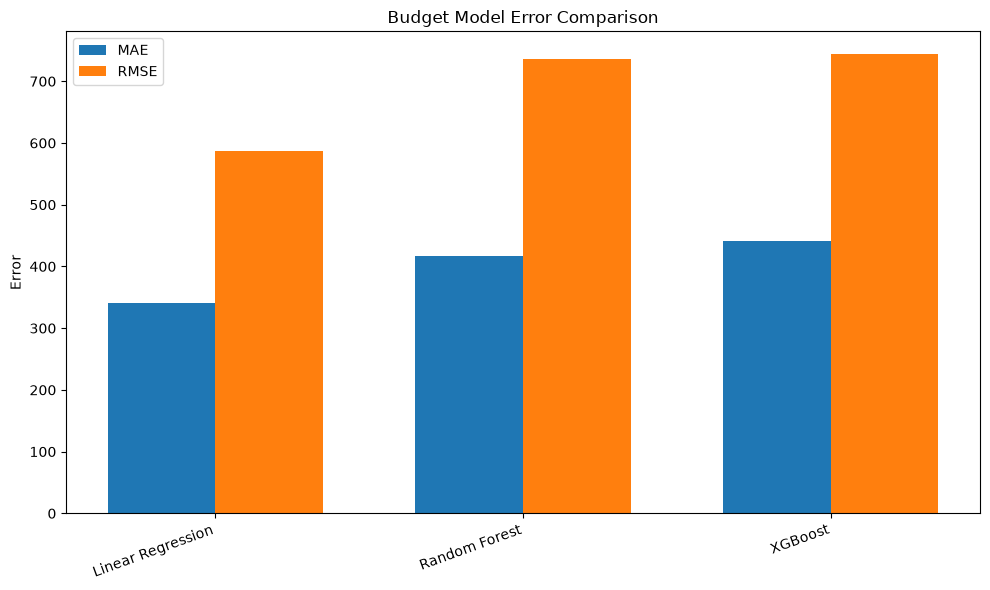

Saved:
c:\Users\bagad\health-budget-ml\outputs\graphs\budget_model_error_comparison.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison))
width = 0.35


ax.bar(
    x - width / 2,
    comparison["MAE"],
    width,
    label="MAE"
)


ax.bar(
    x + width / 2,
    comparison["RMSE"],
    width,
    label="RMSE"
)


ax.set_xticks(x)

ax.set_xticklabels(
    comparison["Model"],
    rotation=20,
    ha="right"
)

ax.set_ylabel("Error")
ax.set_title("Budget Model Error Comparison")

ax.legend()

plt.tight_layout()


error_graph = (
    GRAPH_DIR /
    "budget_model_error_comparison.png"
)

plt.savefig(
    error_graph,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Saved:")
print(error_graph)

# Budget ML evaluation setup

In [9]:
budget_evaluation = pd.DataFrame([
    {
        "Item": "Target",
        "Value": "Expenditure"
    },
    {
        "Item": "Evaluation type",
        "Value": "Chronological holdout"
    },
    {
        "Item": "Training period",
        "Value": "2022–23"
    },
    {
        "Item": "Test period",
        "Value": "2023–24"
    },
    {
        "Item": "Models",
        "Value": ", ".join(
            comparison["Model"].astype(str)
        )
    },
    {
        "Item": "Metrics",
        "Value": "MAE, RMSE, R²"
    }
])


display(budget_evaluation)

,Item,Value
0,Target,Expenditure
1,Evaluation type,Chronological holdout
2,Training period,2022–23
3,Test period,2023–24
4,Models,"Linear Regression, Random Forest, XGBoost"
5,Metrics,"MAE, RMSE, R²"


# Project module comparison

In [10]:
module_comparison = pd.DataFrame([

    {
        "Module": "Budget Allocation",
        "Dataset": "NHM Budget",
        "Task": "Predict Expenditure",
        "Method": "Linear Regression, Random Forest, XGBoost",
        "Evaluation": "MAE, RMSE, R²",
        "Status": "ML prototype completed"
    },

    {
        "Module": "Health / Disease Analytics",
        "Dataset": "HMIS",
        "Task": "Health indicator analysis",
        "Method": "EDA + prototype indicator priority score",
        "Evaluation": "Descriptive statistics and score analysis",
        "Status": "Analytics prototype completed"
    },

    {
        "Module": "Infrastructure",
        "Dataset": "Rural Health Infrastructure",
        "Task": "Infrastructure analysis",
        "Method": "State/year analytics + prototype gap score",
        "Evaluation": "Coverage, missingness and descriptive analysis",
        "Status": "Analytics prototype completed"
    }

])


display(module_comparison)

,Module,Dataset,Task,Method,Evaluation,Status
0,Budget Allocation,NHM Budget,Predict Expenditure,"Linear Regression, Random Forest, XGBoost","MAE, RMSE, R²",ML prototype completed
1,Health / Disease Analytics,HMIS,Health indicator analysis,EDA + prototype indicator priority score,Descriptive statistics and score analysis,Analytics prototype completed
2,Infrastructure,Rural Health Infrastructure,Infrastructure analysis,State/year analytics + prototype gap score,"Coverage, missingness and descriptive analysis",Analytics prototype completed


# Current project status

In [11]:
project_status = pd.DataFrame([

    {
        "Area": "Dataset collection",
        "Status": "Completed"
    },

    {
        "Area": "Data cleaning",
        "Status": "Completed"
    },

    {
        "Area": "EDA",
        "Status": "Completed"
    },

    {
        "Area": "Feature engineering",
        "Status": "Completed"
    },

    {
        "Area": "Budget prediction",
        "Status": "Completed"
    },

    {
        "Area": "XGBoost",
        "Status": "Completed"
    },

    {
        "Area": "Scikit-learn models",
        "Status": "Completed"
    },

    {
        "Area": "Budget model evaluation",
        "Status": "Completed"
    },

    {
        "Area": "Health analytics",
        "Status": "Completed"
    },

    {
        "Area": "Infrastructure analytics",
        "Status": "Completed"
    },

    {
        "Area": "Model comparison",
        "Status": "Current notebook"
    },

    {
        "Area": "Prediction API",
        "Status": "Pending"
    },

    {
        "Area": "Backend integration",
        "Status": "Pending"
    },

    {
        "Area": "Frontend dashboard",
        "Status": "Pending"
    },

    {
        "Area": "Admin dashboard",
        "Status": "Pending"
    },

    {
        "Area": "Final documentation",
        "Status": "Pending"
    }

])


display(project_status)

,Area,Status
0,Dataset collection,Completed
1,Data cleaning,Completed
2,EDA,Completed
3,Feature engineering,Completed
4,Budget prediction,Completed
5,XGBoost,Completed
6,Scikit-learn models,Completed
7,Budget model evaluation,Completed
8,Health analytics,Completed
9,Infrastructure analytics,Completed


# Save everything

In [12]:
comparison_path = (
    REPORT_DIR /
    "budget_model_comparison.csv"
)

module_comparison_path = (
    REPORT_DIR /
    "project_module_comparison.csv"
)

status_path = (
    REPORT_DIR /
    "project_status.csv"
)


comparison.to_csv(
    comparison_path,
    index=False
)


module_comparison.to_csv(
    module_comparison_path,
    index=False
)


project_status.to_csv(
    status_path,
    index=False
)


print("Saved files:")

print(
    comparison_path
)

print(
    module_comparison_path
)

print(
    status_path
)

Saved files:
c:\Users\bagad\health-budget-ml\outputs\reports\budget_model_comparison.csv
c:\Users\bagad\health-budget-ml\outputs\reports\project_module_comparison.csv
c:\Users\bagad\health-budget-ml\outputs\reports\project_status.csv


# Final validation

In [13]:
print("=" * 60)
print("NOTEBOOK 08 FINAL VALIDATION")
print("=" * 60)

print(
    "Budget models compared:",
    len(comparison)
)

print(
    "Lowest MAE model on Notebook 05 test set:",
    lowest_mae_model
)

print(
    "Lowest RMSE model on Notebook 05 test set:",
    lowest_rmse_model
)

print(
    "Highest R² model on Notebook 05 test set:",
    highest_r2_model
)

print(
    "\nHealth module:",
    "Analytics prototype completed"
)

print(
    "Infrastructure module:",
    "Analytics prototype completed"
)

print(
    "\nNotebook 08 completed successfully."
)

NOTEBOOK 08 FINAL VALIDATION
Budget models compared: 3
Lowest MAE model on Notebook 05 test set: Linear Regression
Lowest RMSE model on Notebook 05 test set: Linear Regression
Highest R² model on Notebook 05 test set: Linear Regression

Health module: Analytics prototype completed
Infrastructure module: Analytics prototype completed

Notebook 08 completed successfully.
